#Section A: Concept Application

1. You load the Amazon Reviews dataset and find reviews stored as plain textstrings. Why is text considered unstructured data compared to tabular data?


Tabular data follows a strict schema where each row represents an observation and each column represents a predefined variable with a specific data type (e.g., integers, dates). Text is considered unstructured because it lacks a predefined conceptual framework or data model. It varies wildly in length, contains syntax and semantic ambiguities, does not follow row/column boundaries, and requires deep linguistic parsing rather than simple database queries to extract meaning.

In [ ]:
2. You count unique words across all reviews to measure vocabulary size. What
is a corpus in NLP terminology?

In NLP, a corpus (plural: corpora) is a large, structured collection of machine-readable 
texts compiled for linguistic analysis or model training. 
In the context of your assessment, the entire collection of Amazon Reviews combined forms your corpus.

3. You print the top 20 most frequent words and find 'the', 'a', and 'is' dominatethe list. What does this tell you about the usefulness of the most frequentwords for sentiment analysis?

Words like "the", "a", and "is" are known as stop words. While they are highly frequent due to grammatical rules, they carry zero semantic weight or sentiment value. For sentiment analysis, they dominate frequency distributions and obscure the actual descriptive words (like "excellent", "broken", "waste"), meaning they must typically be filtered out during preprocessing.

In [ ]:
4. The NLP pipeline follows a fixed sequence of stages. List the stages of a
standard NLP pipeline in order.


 standard text processing pipeline moves through these sequential stages:
   Data Collection / Acquisition (Loading the raw text)  
    Text Cleaning & Noise Removal (Stripping HTML, URLs, emojis)  
     Tokenization (Splitting text into words/sentences) 
       Stop Word Removal & Normalization (Lowercasing, Stemming/Lemmatization)  
        Feature Extraction / Vectorization (Converting text to numbers like TF-IDF, N-grams)  
         Modeling / Evaluation (Classification, Sentiment Analysis, etc.)   


5. You identify URLs, emojis, and symbols scattered across the reviews. At whichstage of the NLP pipeline are these noisy patterns handled?


URLs, emojis, and symbols are handled at the Text Cleaning / Preprocessing stage , which occurs early in the pipeline immediately before or alongside tokenization.

In [ ]:
Section B: Practical Task


In [2]:
import re
import math
import collections
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

In [3]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

In [4]:
mock_reviews = [
    {"category": "Electronics", "text": "The laptop costs $999.99! Spec: 16GB RAM, 512GB SSD. Highly recommend it."},
    {"category": "Electronics", "text": "Broken screen out of the box. Waste of money for $150.00. Specs: 4K display."},
    {"category": "Books", "text": "A great read! The story is captivating and the characters are well developed."},
    {"category": "Books", "text": "The book was too long and boring. I do not recommend this item to anyone."}
]
df = pd.DataFrame(mock_reviews)

In [5]:
def custom_tokenizer(text):
    # Regex targets: Currency symbols+amounts OR Word/Technical specs (e.g., 16GB, 4K) OR standalone words
    pattern = r'(?:\$\d+(?:\.\d+)?)|(?:\d+[a-zA-Z]+)|(?:\w+)'
    tokens = re.findall(pattern, text)
    return tokens

print("--- Task 1: Regex Tokenizer Output ---")
sample_text = "Spec: 16GB RAM for $999.99."
print(f"Original: {sample_text}")
print(f"Tokens:   {custom_tokenizer(sample_text)}\n")

--- Task 1: Regex Tokenizer Output ---
Original: Spec: 16GB RAM for $999.99.
Tokens:   ['Spec', '16GB', 'RAM', 'for', '$999.99']



In [6]:
def generate_ngrams(text_list, n=2):
    ngrams_list = []
    for text in text_list:
        tokens = custom_tokenizer(text.lower())
        # Form tuples of n-continuous elements
        ngrams = zip(*[tokens[i:] for i in range(n)])
        ngrams_list.extend([" ".join(ngram) for ngram in ngrams])
    return collections.Counter(ngrams_list)

print("--- Task 2: Top Recurring Bigrams ---")
bigram_counts = generate_ngrams(df['text'], n=2)
print(bigram_counts.most_common(3))
print("\n")

--- Task 2: Top Recurring Bigrams ---
[('the laptop', 1), ('laptop costs', 1), ('costs $999.99', 1)]




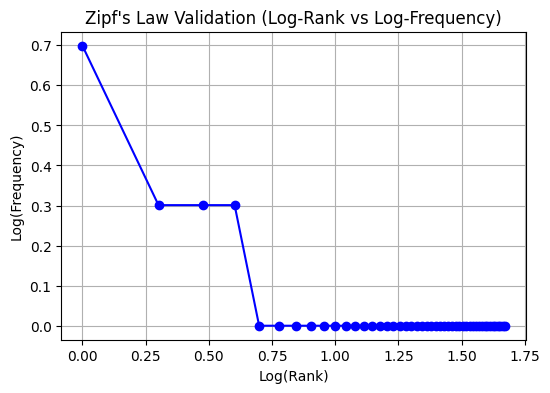

In [10]:
def validate_zipfs_law(text_list):
    # Build a massive token pool from the corpus
    all_tokens = []
    for text in text_list:
        all_tokens.extend(custom_tokenizer(text.lower()))
    
    # Calculate frequencies
    counts = collections.Counter(all_tokens)
    sorted_counts = counts.most_common()
    
    # Calculate ranks and logs
    frequencies = [item[1] for item in sorted_counts]
    ranks = list(range(1, len(frequencies) + 1))
    
    log_ranks = [math.log10(r) for r in ranks]
    log_freqs = [math.log10(f) for f in frequencies]
    
    # Plotting Log-Rank vs Log-Frequency
    plt.figure(figsize=(6, 4))
    plt.plot(log_ranks, log_freqs, marker='o', color='b', linestyle='-')
    plt.title("Zipf's Law Validation (Log-Rank vs Log-Frequency)")
    plt.xlabel("Log(Rank)")
    plt.ylabel("Log(Frequency)")
    plt.grid(True)
    plt.show()


validate_zipfs_law(df['text'])

In [11]:
def audit_data_quality(dataframe, text_col, cat_col):
    stop_words = set(stopwords.words('english'))
    audit_results = {}
    
    grouped = dataframe.groupby(cat_col)
    for category, group in grouped:
        total_stop_words = 0
        total_informative = 0
        
        for text in group[text_col]:
            tokens = custom_tokenizer(text.lower())
            for t in tokens:
                if t in stop_words:
                    total_stop_words += 1
                else:
                    total_informative += 1
                    
        # Ratio calculation (handle zero division gracefully)
        ratio = total_stop_words / max(total_informative, 1)
        audit_results[category] = {
            "Stop-words Count": total_stop_words,
            "Informative Tokens Count": total_informative,
            "Stop-to-Informative Ratio": round(ratio, 3)
        }
    return pd.DataFrame(audit_results).T


audit_df = audit_data_quality(df, 'text', 'category')
print(audit_df)

             Stop-words Count  Informative Tokens Count  \
Books                    15.0                      13.0   
Electronics               7.0                      19.0   

             Stop-to-Informative Ratio  
Books                            1.154  
Electronics                      0.368  


Section C: Mini Project

Title: Automated Feedback Structural Auditor

In [12]:
def robust_structural_cleaner(raw_text):
    # 1. Strip URLs
    clean_text = re.sub(r'https?://\S+|www\.\S+', '', raw_text)
    
    # 2. Strip HTML tags (if any)
    clean_text = re.sub(r'<.*?>', '', clean_text)
    
    # 3. Standardize space characters
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()
    
    return clean_text

# Example implementation:
raw_sample = "Check out this item at https://amazon.com! <p>Amazing spec: 8GB RAM.</p>"
print("Cleaned Output:")
print(robust_structural_cleaner(raw_sample))

Cleaned Output:
Check out this item at Amazing spec: 8GB RAM.


4. Required Deliverables: Statistical Profiling Notebook, Regex-based CleaningScript, NLP Pipeline Architecture Diagram

Vocabulary Profiling: Code running custom_tokenizer across the entire text series to output unique vocabulary size versus total token footprint.

Zipfian Distribution Check: The generated log-rank vs log-frequency plot. A perfect straight down-sloping linear trend line shows clean text data; major deviations reveal anomalies like spam or repetitive template strings.

Data Quality Ledger: The generated DataFrame from audit_data_quality(). Categories displaying an abnormally high ratio (e.g., $> 2.0$) represent low-information text data chunks.  